In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle

from datasets.dataset import HARClassifierDataset, generate_activity_sequence
from datasets.sparse_data_utils import SparseHarDataset
from energy_harvesting.energy_harvest import EnergyHarvester
from energy_harvesting.harvesting_sensor import EnergyHarvestingSensor
from utils.setup_funcs import PROJECT_ROOT, MODEL_ROOT, DATA_ROOT, init_logger, init_seeds

MODEL ROOT /home/gc28692/BHAR_codes_artifact


# Load an Activity Sequence

In [2]:
# settings
dataset = "dsads"
architecture = "tinyhar"
test_subjects = [3]
sensor_list = ['acc']
seed = 0

# grab dataset metadata
with open(os.path.join(DATA_ROOT[dataset],"preprocessed_data",'metadata.pickle'), 'rb') as handle:
	dataset_info = pickle.load(handle)

body_part_list = [list(dataset_info['sensor_channel_map'].keys())[-1]]
activity_list = list(dataset_info['label_map'].keys())
train_subjects = dataset_info['list_of_subjects']

# experiments settings
kwargs = { 
                    'dataset_dir': os.path.join(DATA_ROOT[dataset],"preprocessed_data"),
                    'subjects': train_subjects, 
                    'sensors': sensor_list, 
                    'body_parts': body_part_list , 
                    'activities': activity_list,
                    'val_frac': 0.1, 
                    'window_size': 8, 
                    'overlap_frac': 0.5, 
                    'normalize': False,
					'harvesting_sensor_window_size': 8,
					'leakage': 6.6e-6,
					'tx_thresh': 50e-6,
					'harvest_efficiency': 0.5,
					'init_energy': 0,
					'sampling_frequency': 25,
					'max_energy': 200e-6,
					'policy_frequency': 5,
					'unconstrained_stride': 12
}

train_ds = HARClassifierDataset(**kwargs,train=True,val=False)
val_ds = HARClassifierDataset(**kwargs,train=False,val=True)
kwargs['subjects'] = test_subjects
test_ds = HARClassifierDataset(**kwargs,train=False,val=False)

# create sequence
train_data = np.concatenate(list(train_ds.raw_data.values()))
train_labels = np.concatenate(list(train_ds.raw_labels.values()))

val_data = np.concatenate(list(val_ds.raw_data.values()))
val_labels = np.concatenate(list(val_ds.raw_labels.values()))

test_data = np.concatenate(list(test_ds.raw_data.values()))
test_labels = np.concatenate(list(test_ds.raw_labels.values()))

sensor_channel_map = train_ds.dataset_info['sensor_channel_map']
active_channels = train_ds.active_channels
# -------------------

min_dur = 10
max_dur = 30
np.random.seed(seed)
train_data_sequence, train_label_sequence = generate_activity_sequence(train_data,train_labels,min_dur,max_dur,kwargs['sampling_frequency'])
val_data_sequence, val_label_sequence = generate_activity_sequence(val_data,val_labels,min_dur,max_dur,kwargs['sampling_frequency'])
test_data_sequence, test_label_sequence = generate_activity_sequence(test_data,test_labels,min_dur,max_dur,kwargs['sampling_frequency'])


# normalize data used for classification, unormalized used for energy harvesting
normalized_train_data_sequence = (train_data_sequence-train_ds.mean)/(train_ds.std + 1e-5)
normalized_val_data_sequence = (val_data_sequence-train_ds.mean)/(train_ds.std + 1e-5)
normalized_test_data_sequence = (test_data_sequence-train_ds.mean)/(train_ds.std + 1e-5)

# prepare environment
eh = EnergyHarvester(tx_thresh=kwargs['tx_thresh'],
					 efficiency=kwargs['harvest_efficiency'])
ehs = EnergyHarvestingSensor(eh, 
						kwargs['harvesting_sensor_window_size'], 
						kwargs['leakage'], 
						kwargs['sampling_frequency'],
						kwargs['max_energy'],
						kwargs['policy_frequency'],
						kwargs['init_energy'])

# ---------------------------
policies = ['unconstrained','opportunistic','conservative']
sparse_datasets = {}
e_traces = {}
tau_trace = []
p_trace = []
en_trace = []
pn_trace = []
packet_idxs = {}
policy_params = None

for policy_name in policies:

	if 'conservative' in policy_name:
		logging_prefix = f'{dataset}/{architecture}'
		policy_ckpt_path = os.path.join(MODEL_ROOT,"saved_data_cached/checkpoints",f"{os.path.dirname(logging_prefix)}/conservative-asynchronous_single_sensor/policy_{test_subjects}_seed{seed}")+'.pkl'
		with open(policy_ckpt_path, 'rb') as file:
			policy = pickle.load(file)['best']
			policy_params = policy
		for bp in kwargs['body_parts']:
			policy[bp] = f"conservative_{policy[bp][0]}_{policy[bp][1]}"
	# opportunistic or unconstrained for all sensors
	elif policy_name == 'unconstrained':
		stride = kwargs['unconstrained_stride']
		policy = {bp: policy_name+f"_{stride}" for bp in kwargs['body_parts']}
	elif policy_name == 'opportunistic':
		policy = {bp: policy_name for bp in kwargs['body_parts']}

	test_packet_idxs = {}
	per_bp_data_test = {}
	e_trace = []
	for bp in kwargs['body_parts']:
		bp_channels = np.where(np.isin(active_channels,sensor_channel_map[bp]['acc']))[0]
		per_bp_data_test[bp] = normalized_test_data_sequence[:,bp_channels]
		
		test_packet_idxs[bp] = ehs.sparsify_data(policy[bp], test_data_sequence[:,bp_channels])
		e_trace.append(ehs.e_trace)
		if 'conservative' in policy_name:
			tau_trace.append(ehs.tau_trace)
			p_trace.append(ehs.p_trace)
			en_trace.append(ehs.en_trace)
			pn_trace.append(ehs.pn_trace)
	sparse_test_ds = SparseHarDataset(per_bp_data_test, test_label_sequence, test_packet_idxs)

	sparse_datasets[policy_name] = sparse_test_ds
	packet_idxs[policy_name] = test_packet_idxs
	if policy_name != 'unconstrained':
		e_traces[policy_name] = e_trace

# -------------------------

========= Building Training Dataset =========
Body Parts: ['left_leg']
Sensors:  ['acc']
Active Channels: [36 37 38]
Subjects: [1, 2, 3, 4, 5, 6, 7, 8]
Activities: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Label Map: {0: 'sitting', 1: 'standing', 2: 'lying on back', 3: 'lying on right side', 4: 'ascending stairs', 5: 'descending stairs', 6: 'standing in elevator', 7: 'moving in elevator', 8: 'walking in parking lot', 9: 'walking on flat treadmill', 10: 'walking on inclined treadmill', 11: 'running on treadmill,', 12: 'exercising on stepper', 13: 'exercising on cross trainer', 14: 'cycling on exercise bike horizontal', 15: 'cycling on exercise bike vertical', 16: 'rowing', 17: 'jumping', 18: 'playing basketball'}
========= Building Val Dataset =========
Body Parts: ['left_leg']
Sensors:  ['acc']
Active Channels: [36 37 38]
Subjects: [1, 2, 3, 4, 5, 6, 7, 8]


Activities: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Label Map: {0: 'sitting', 1: 'standing', 2: 'lying on back', 3: 'lying on right side', 4: 'ascending stairs', 5: 'descending stairs', 6: 'standing in elevator', 7: 'moving in elevator', 8: 'walking in parking lot', 9: 'walking on flat treadmill', 10: 'walking on inclined treadmill', 11: 'running on treadmill,', 12: 'exercising on stepper', 13: 'exercising on cross trainer', 14: 'cycling on exercise bike horizontal', 15: 'cycling on exercise bike vertical', 16: 'rowing', 17: 'jumping', 18: 'playing basketball'}
========= Building Test Dataset =========
Body Parts: ['left_leg']
Sensors:  ['acc']
Active Channels: [36 37 38]
Subjects: [3]
Activities: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
Label Map: {0: 'sitting', 1: 'standing', 2: 'lying on back', 3: 'lying on right side', 4: 'ascending stairs', 5: 'descending stairs', 6: 'standing in elevator', 7: 'moving in elevator', 8: 'walking in parking lot', 

# Plot Active and Passive

standing in elevator


/tmp/ipykernel_2919138/1299064452.py:43: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax[-2].scatter(t_global[sent_idxs_c[s_loc_c]],test_label_sequence[sent_idxs_c[s_loc_c]]+.85,c='tab:blue',label=r'$\mathcal{M}_{\pi}$, Sent Packets (Conservative)',s=200,facecolors='none',marker='v')
/tmp/ipykernel_2919138/1299064452.py:48: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax[-1].scatter(t_global[sent_idxs_o[s_loc_o]],test_label_sequence[sent_idxs_o[s_loc_o]]+.85,c='gray',label=r'$\mathcal{M}_{\pi}$, Sent Packets (Opportunistic)',s=200,facecolors='none',marker='v')


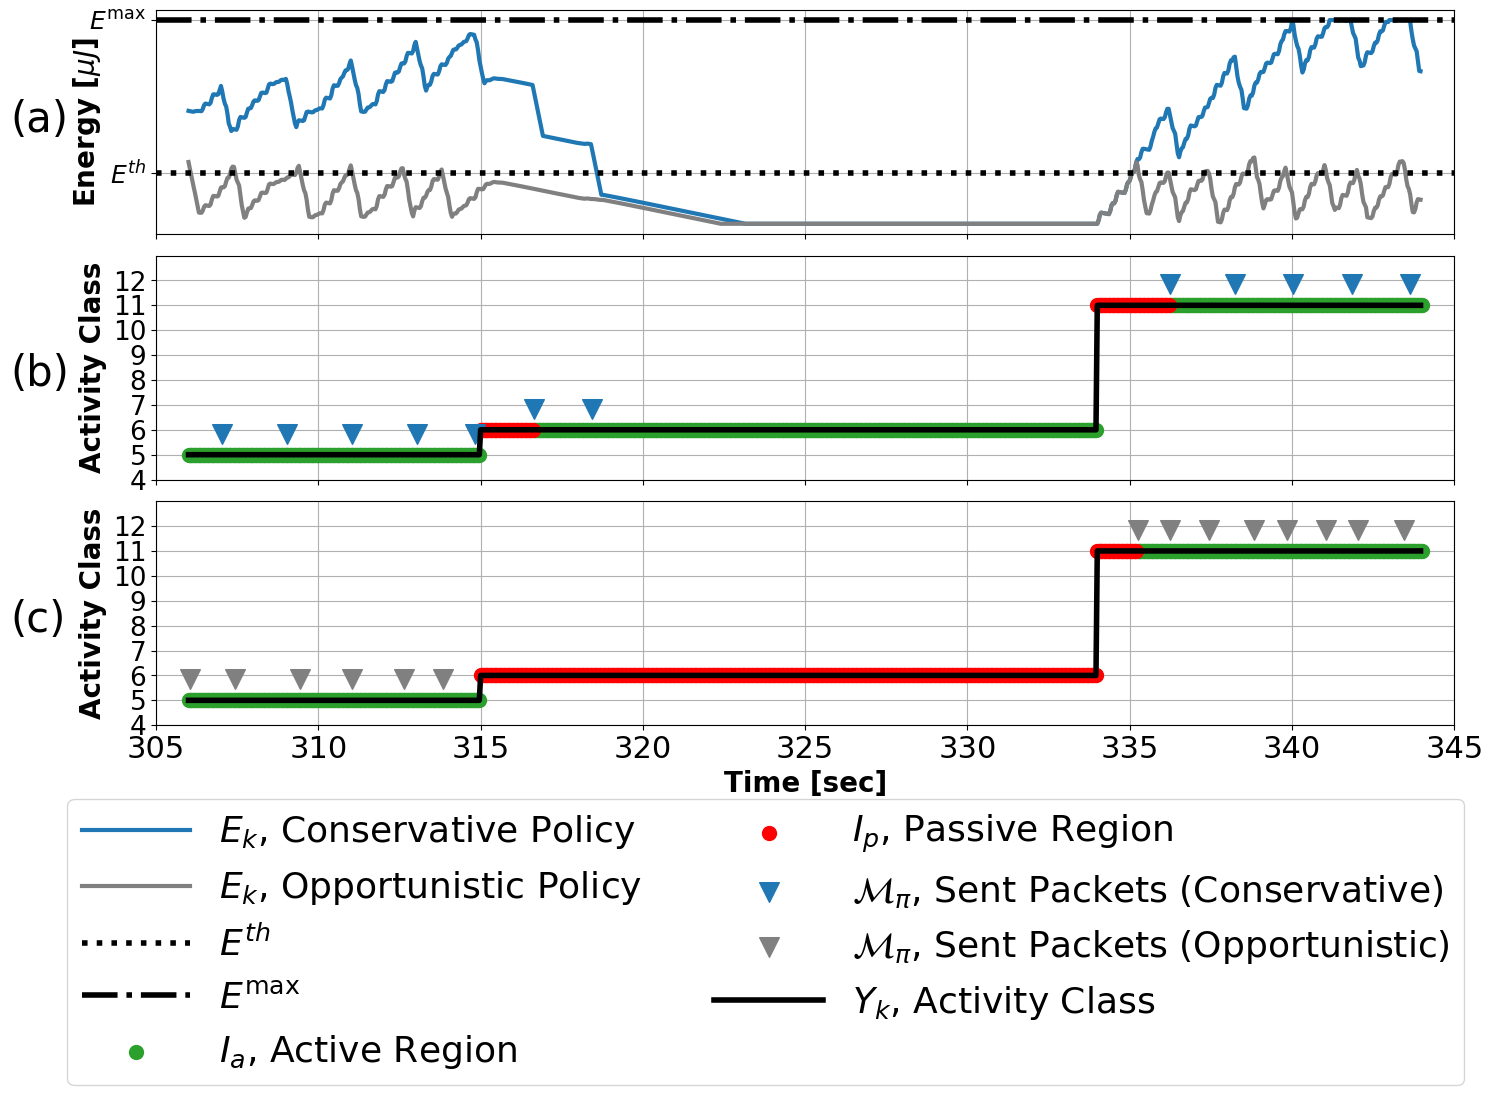

In [3]:
st = 300*25+150
en = 300*25+1100
print(dataset_info['label_map'][test_label_sequence[st+500]])
t = np.arange(st,en)/25
t_global = np.arange(len(normalized_test_data_sequence))/25
policy = 'conservative'

fig,ax = plt.subplots(len(body_part_list)+2,1,figsize=(14,8))

for i,bp in enumerate(body_part_list):
    ax[i].tick_params(axis='both', which='major', labelsize=18)
    ax[i].plot(t,e_traces[policy][body_part_list.index(bp)][st:en]*10e5,c='tab:blue',linewidth=3,label=r"$E_k$, Conservative Policy")
    ax[i].plot(t,e_traces['opportunistic'][body_part_list.index(bp)][st:en]*10e5,c='gray',linewidth=3,label=r"$E_k$, Opportunistic Policy")
    ax[i].axhline(50e-6*10e5,c='k',linewidth=4,linestyle=':',label=r'$E^{th}$')
    ax[i].axhline(200e-6*10e5,c='k',linewidth=4,label=r'$E^{\text{max}}$',linestyle='-.')

    ax[i].grid()
    ax[i].set_xticklabels([])
    ax[i].set_ylabel(r"Energy [$\mu J$]",fontsize=20,fontweight='bold',labelpad=-10)

    s_idxs = packet_idxs[policy][bp][:,1]
    s_idxs = s_idxs[(s_idxs > st) & (s_idxs < en)]
# Collect handles and labels from both subplots

active_idxs_c,passive_idxs_c = sparse_datasets[policy].region_decomposition()
active_idxs_o,passive_idxs_o = sparse_datasets['opportunistic'].region_decomposition()

sent_idxs_c = sparse_datasets[policy].unique_packet_timestamps[:,0]
sent_idxs_o = sparse_datasets['opportunistic'].unique_packet_timestamps[:,0]

a_loc_c = (active_idxs_c >= st) & (active_idxs_c <= en)
p_loc_c = (passive_idxs_c >= st) & (passive_idxs_c <= en)
s_loc_c = (sent_idxs_c >= st) & (sent_idxs_c <= en)
a_loc_o = (active_idxs_o >= st) & (active_idxs_o <= en)
p_loc_o = (passive_idxs_o >= st) & (passive_idxs_o <= en)
s_loc_o = (sent_idxs_o >= st) & (sent_idxs_o <= en)

ax[0].set_yticks([50,200],[r'$E^{th}$',r'$E^{\text{max}}$'])

ax[-2].scatter(t_global[active_idxs_c[a_loc_c]],test_label_sequence[active_idxs_c[a_loc_c]],c='tab:green',label=r'$I_a$, Active Region',s=100)
ax[-2].scatter(t_global[passive_idxs_c[p_loc_c]],test_label_sequence[passive_idxs_c[p_loc_c]],c='r',label=r'$I_p$, Passive Region',s=100)
# ax[-1].scatter(t_global[sent_idxs_c[s_loc_c]],np.zeros_like(sent_idxs_c[s_loc_c]),c='blue',label='sent',s=60,alpha=0.15,edgecolors='k')
ax[-2].scatter(t_global[sent_idxs_c[s_loc_c]],test_label_sequence[sent_idxs_c[s_loc_c]]+.85,c='tab:blue',label=r'$\mathcal{M}_{\pi}$, Sent Packets (Conservative)',s=200,facecolors='none',marker='v')

ax[-1].scatter(t_global[active_idxs_o[a_loc_o]],test_label_sequence[active_idxs_o[a_loc_o]],c='tab:green',s=100)
ax[-1].scatter(t_global[passive_idxs_o[p_loc_o]],test_label_sequence[passive_idxs_o[p_loc_o]],c='r',s=100)
# ax[-1].scatter(t_global[sent_idxs_o[s_loc_o]],np.zeros_like(sent_idxs_o[s_loc_o])-5,c='gray',label='sent',s=60,alpha=0.15)
ax[-1].scatter(t_global[sent_idxs_o[s_loc_o]],test_label_sequence[sent_idxs_o[s_loc_o]]+.85,c='gray',label=r'$\mathcal{M}_{\pi}$, Sent Packets (Opportunistic)',s=200,facecolors='none',marker='v')
ax[-2].set_xticklabels([])

ax[-1].plot(t,test_label_sequence[st:en],linewidth=4,c='k',label=r'$Y_k$, Activity Class')
ax[-2].plot(t,test_label_sequence[st:en],linewidth=4,c='k')
ax[-2].set_ylim([4,13])
ax[-1].set_ylim([4,13])
ax[-1].set_yticks(np.arange(4,13))
ax[-2].set_yticks(np.arange(4,13))
ax[-1].tick_params(axis='both', which='major', labelsize=19)
ax[-1].tick_params(axis='x', which='major', labelsize=22)
ax[-2].tick_params(axis='both', which='major', labelsize=19)
ax[-1].set_ylabel("Activity Class",fontsize=20,fontweight='bold')
ax[-2].set_ylabel("Activity Class",fontsize=20,fontweight='bold')
ax[-1].set_xlabel("Time [sec]",fontsize=20,fontweight='bold')
ax[-1].grid()
ax[-2].grid()

ax[0].set_axisbelow(True)
ax[1].set_axisbelow(True)
ax[2].set_axisbelow(True)



handles1, labels1 = ax[0].get_legend_handles_labels()
handles2, labels2 = ax[1].get_legend_handles_labels()
handles3, labels3 = ax[2].get_legend_handles_labels()

# Combine them
handles = handles1 + handles2 + handles3
labels = labels1 + labels2 + labels3
fig.legend(handles, labels, loc="lower center", ncol=2,fontsize=26,handlelength=3,  bbox_to_anchor=(0.5, -0.375)) 

plt.tight_layout(pad=0.4)
ax[0].set_xlim([305,345])
ax[1].set_xlim([305,345])
ax[2].set_xlim([305,345])
ax[0].text(300.5,90,"(a)",fontsize=30)
ax[1].text(300.5,7.75,"(b)",fontsize=30)
ax[2].text(300.5,7.75,"(c)",fontsize=30)
plt.savefig("regions.pdf",bbox_inches='tight')